# BEE 4750 Lab 2: Monte Carlo

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/Desktop/lab-2-mai58-11`
   Installed Xorg_libXfixes_jll ─────── v6.0.2+0
   Installed Libuuid_jll ────────────── v2.41.2+0
   Installed Xorg_xcb_util_cursor_jll ─ v0.1.6+0
   Installed Libmount_jll ───────────── v2.41.2+0
   Installed Libtiff_jll ────────────── v4.7.2+0
   Installed Plots ──────────────────── v1.41.1
Precompiling project...
    939.8 ms  ✓ SortingAlgorithms
    859.2 ms  ✓ Libmount_jll
    858.3 ms  ✓ Libuuid_jll
    860.9 ms  ✓ Xorg_libXfixes_jll
   1184.3 ms  ✓ Libtiff_jll
   1398.9 ms  ✓ ColorVectorSpace → SpecialFunctionsExt
    644.8 ms  ✓ Xorg_xcb_util_cursor_jll
    964.4 ms  ✓ Fontconfig_jll
    863.1 ms  ✓ Cairo_jll
   1882.7 ms  ✓ StatsBase
   1208.5 ms  ✓ Qt6Base_jll
    754.4 ms  ✓ HarfBuzz_jll
   3711.6 ms  ✓ ColorSchemes
    826.3 ms  ✓ libass_jll
    873.5 ms  ✓ Pango_jll
   1295.3 ms  ✓ Qt6ShaderTools_jll
   1223.8 ms  ✓ FFMPEG_jll
   1495.4 ms  ✓ Qt6Declarative_jll
   1058.3 ms  ✓ FFMPEG
   3998.4 ms  ✓ Distributions
   1481.

In [2]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [3]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [6]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 6
 5
 6
 5
 5
 6
 2
 5
 4
 6
 ⋮
 4
 2
 5
 3
 4
 3
 5
 5
 1

And then we can plot a histogram of these rolls:

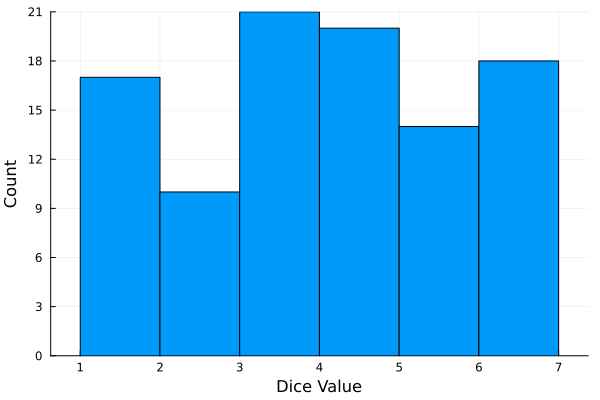

In [7]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

===== Monte Carlo results (N = 200000, seed = 1234) =====
LogNormal(1.2, 0.3):      E[d] = 115144.43   Q0.99[d] = 189746.56
GEV(μ=3, σ=0.9, ξ=-0.15): E[d] = 113394.77  Q0.99[d] = 183200.79


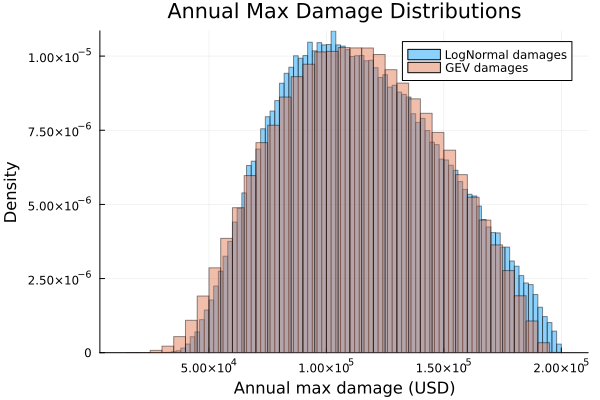

In [17]:
# --- 1) Depth–damage function ---
const L  = 200_000.0
const k  = 0.8
const h0 = 3.0

damage(h; L=L, k=k, h0=h0) = h > 0 ? L / (1 + exp(-k*(h - h0))) : 0.0

# --- 2) Hazard distributions ---
dist_lognormal = LogNormal(1.2, 0.3)

function rand_gev(rng::AbstractRNG, ξ::Float64, μ::Float64, σ::Float64, n::Int)
    U = rand(rng, n)  # uniform(0,1)
    if ξ != 0
        return μ .+ (σ/ξ) .* ((-log.(U)).^(-ξ) .- 1.0)
    else
        return μ .- σ .* log.(-log.(U))   # Gumbel case ξ=0
    end
end

# --- 3) Monte Carlo sampling & mapping ---
seed = 1234
Random.seed!(seed)
N = 200_000

h_ln  = rand(dist_lognormal, N)
h_gev = rand_gev(Random.default_rng(), -0.15, 3.0, 0.9, N)

dam_ln  = damage.(h_ln)
dam_gev = damage.(h_gev)

# --- 4) Summary stats ---
mean_ln  = mean(dam_ln);   q99_ln  = quantile(dam_ln, 0.99)
mean_gev = mean(dam_gev);  q99_gev = quantile(dam_gev, 0.99)

println("===== Monte Carlo results (N = $N, seed = $seed) =====")
println("LogNormal(1.2, 0.3):      E[d] = $(round(mean_ln, digits=2))   Q0.99[d] = $(round(q99_ln, digits=2))")
println("GEV(μ=3, σ=0.9, ξ=-0.15): E[d] = $(round(mean_gev, digits=2))  Q0.99[d] = $(round(q99_gev, digits=2))")

# --- 5) Plots ---

# (a) Depth–damage curve
hs = range(0, 8, length=400)
plot(hs, damage.(collect(hs));
     xlabel="Depth h (m)", ylabel="Damage (USD)",
     lw=2, legend=false, title="Depth–Damage Logistic Function")

# (b) Damage histograms (overlay, density-scaled)
p = histogram(dam_ln; bins=80, normalize=:pdf, alpha=0.45,
              label="LogNormal damages", xlabel="Annual max damage (USD)",
              ylabel="Density", title="Annual Max Damage Distributions")
histogram!(p, dam_gev; bins=80, normalize=:pdf, alpha=0.45, label="GEV damages")
display(p)


**Problem**
The Monte Carlo simulation produced consistent estimates of annual maximum damage under both hazard models. For the LogNormal(1.2, 0.3) distribution, the expected damage was about $115,144, with the 99% quantile at approximately $189,747. For the Generalized Extreme Value (μ = 3, σ = 0.9, ξ = −0.15) distribution, the expected damage was slightly lower, around $113,395, with the 99% quantile at about $183,201. These results suggest that both hazard assumptions yield similar damage outcomes within the functional form of the depth–damage relationship.

The sample size of 200,000 was chosen to ensure stable estimates of both the mean and the high quantile. While expected values converge quickly with fewer samples, the 99% quantile is located in the far tail of the distribution and is therefore more sensitive to variability. Convergence checks indicated that values continued to fluctuate at lower sample sizes, but stabilized around 100,000 to 200,000 draws, making 200,000 a reasonable balance between computational efficiency and statistical reliability.

The similarity in results between the two hazard distributions arises from the form of the depth–damage curve. The logistic function rises sharply around the threshold depth of 3 meters but then plateaus near the maximum damage of $200,000. As a result, differences in the tails of the flood hazard distributions beyond 4–5 meters have limited influence on the damage statistics, since damages are capped. Both the LogNormal and GEV produce many values in the mid-range depths where damages change most steeply, leading to similar expected values and quantiles despite differences in their statistical definitions.

Deciding which distribution is “better” requires more than comparing Monte Carlo outcomes. The choice depends on how well each model reflects observed annual flood maxima. The GEV distribution has a theoretical foundation in extreme value theory, which often makes it more appropriate for modeling block maxima such as annual peak floods. The LogNormal, by contrast, may be easier to use when processes are thought to be multiplicative. Ultimately, selecting the best model would require fitting both to real hydrologic data, evaluating their goodness-of-fit, and validating their ability to capture extreme tail behavior, especially if policy or design decisions depend on very rare, high-damage events.

## References

Put any consulted sources here, including classmates you worked with/who
helped you.